In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import linear_model, preprocessing
from src.helper import get_split_data

In [2]:
X_trn, y_trn, X_val, y_val, X_tst, y_tst = get_split_data.split_data_for_training(7, 'data/preprocessed/imputed_data.csv', 17)

In [3]:
std = preprocessing.StandardScaler()
lr = linear_model.LogisticRegression()
lr.fit(std.fit_transform(X_trn), y_trn)
lr.score(std.transform(X_tst), y_tst)

0.6

<Axes: >

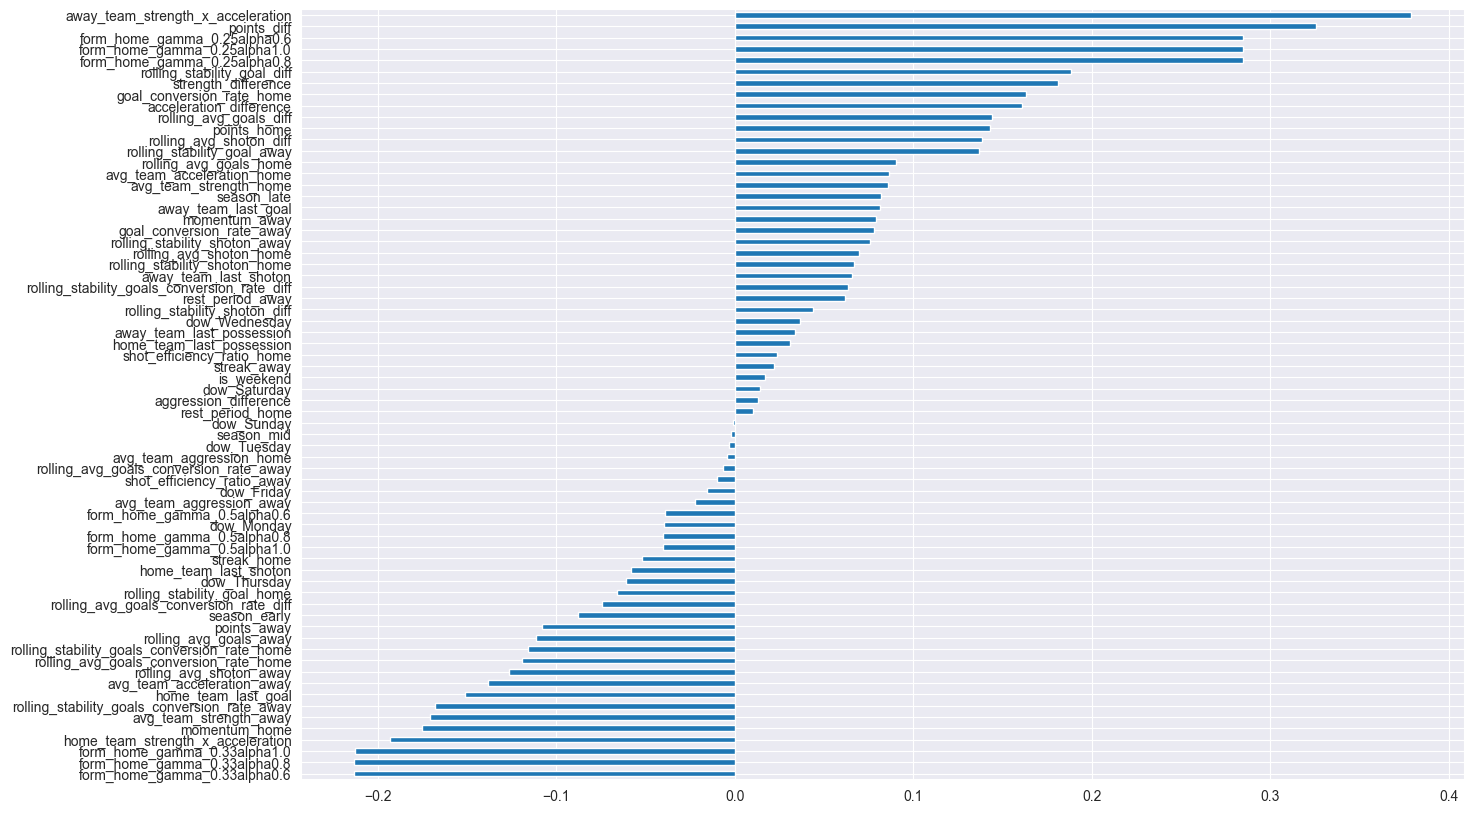

In [4]:
fig, ax = plt.subplots(figsize=(15, 10))
(pd.Series(lr.coef_[0], index=X_trn.columns)
 .sort_values()
 .plot.barh(ax=ax)
)

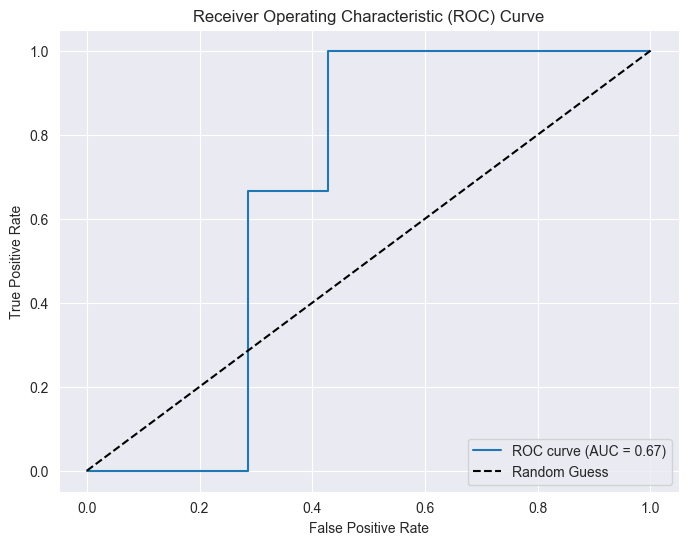

In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_proba = lr.predict_proba(std.transform(X_tst))[:, 1]

fpr, tpr, thresholds = roc_curve(y_tst, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

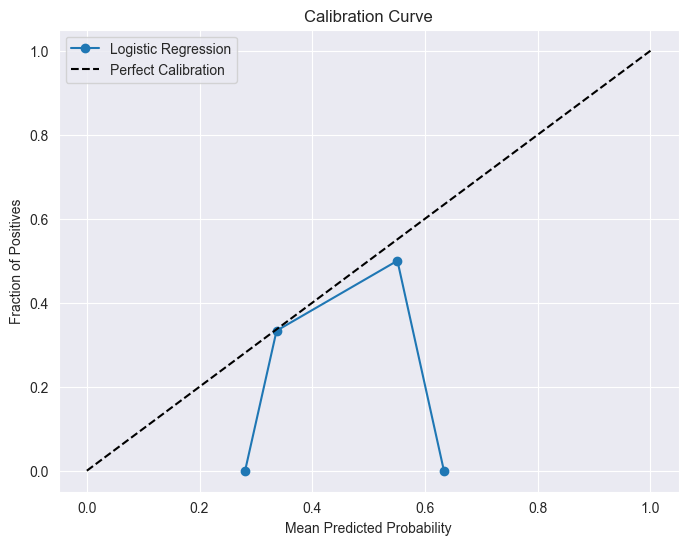

In [7]:
from sklearn.calibration import calibration_curve

y_proba = lr.predict_proba(std.transform(X_tst))[:, 1]

prob_true, prob_pred = calibration_curve(y_tst, y_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend(loc='upper left')
plt.show()
